# Question 9

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import json

path = "/content/drive/MyDrive/Data Part 2/"
hashtags = ["gohawks", "gopatriots", "nfl", "patriots", "sb49", "superbowl"]

def count(file_path):
    c = 0
    with open(file_path, 'r') as f:
        for line in f:
            c+=1
    return c

hashtags = {h: {"file_name": "tweets_#" + h + ".txt",
                "file_path": path + "tweets_#" + h + ".txt",
                "count": count(path + "tweets_#" + h + ".txt")}
            for h in hashtags}

attributes = ['firstpost_date', 'title', 'url', 'tweet', 'author', 'original_author', 'citation_date', 'metrics', 'highlight', 'type', 'citation_url']

for h in hashtags:
    print("#" + h + " "*(10-len(h)), (7-len(str(hashtags[h]["count"])))*" " + str(hashtags[h]["count"]), "tweets")

#gohawks     169122 tweets
#gopatriots   23511 tweets
#nfl         233022 tweets
#patriots    440621 tweets
#sb49        743649 tweets
#superbowl  1213813 tweets


In [14]:
import math

class TweetDataLoader:
    def __init__(self, hashtag, batch_size=0):
        self.hashtag = hashtag
        self.file_path = hashtags[self.hashtag]["file_path"]
        self.total_count = hashtags[self.hashtag]["count"]
        self.batch_size = batch_size
        if self.batch_size > 0:
            self._length = math.ceil(self.total_count / self.batch_size)
        else:
            self._length = self.total_count

        self.f = open(self.file_path, 'r', encoding='utf-8')
        self.offsets = []
        self._build_index()

    def _build_index(self):
        """Builds a list of byte offsets for each line in the file."""
        self.f.seek(0)
        pos = self.f.tell()
        line = self.f.readline()
        while line:
            self.offsets.append(pos)
            pos = self.f.tell()
            line = self.f.readline()

    def __len__(self):
        return self._length

    def __getitem__(self, index):
        if self.batch_size == 0:
            # Single-item mode.
            if index < 0:
                index = self.total_count + index
            if index < 0 or index >= self.total_count:
                raise IndexError("Index out of range")
            self.f.seek(self.offsets[index])
            line = self.f.readline()
            return json.loads(line)
        else:
            # Batch mode.
            if index < 0:
                index = self._length + index
            if index < 0 or index >= self._length:
                raise IndexError("Batch index out of range")
            start_index = index * self.batch_size
            end_index = min(start_index + self.batch_size, self.total_count)
            batch = []
            for i in range(start_index, end_index):
                self.f.seek(self.offsets[i])
                line = self.f.readline()
                batch.append(json.loads(line))
            return batch

    def __del__(self):
        self.f.close()

In [15]:
for h in hashtags:
  exec(h+"Loader = TweetDataLoader('"+h+"')")
  exec("hashtags[h][\"loader\"] = "+h+"Loader")

In [ ]:
from datetime import datetime, timedelta

def compute_stats(loader):
    total_tweets = len(loader)
    total_followers = 0
    total_retweets = 0
    min_time = None
    max_time = None

    for i in range(total_tweets):
        tweet = loader[i]
        tweet_time = datetime.fromtimestamp(tweet['citation_date'])
        if min_time is None or tweet_time < min_time:
            min_time = tweet_time
        if max_time is None or tweet_time > max_time:
            max_time = tweet_time
        total_followers += tweet['author']['followers']
        total_retweets += tweet['metrics']['citations']['total']

    total_seconds = (max_time - min_time).total_seconds() if min_time and max_time else 0
    total_hours = total_seconds / 3600.0 if total_seconds > 0 else 1

    avg_tweets_per_hour = total_tweets / total_hours
    avg_followers = total_followers / total_tweets
    avg_retweets = total_retweets / total_tweets

    return avg_tweets_per_hour, avg_followers, avg_retweets, min_time, max_time

stats_results = {}

for h in hashtags:
    print(f"Computing statistics for #{h}:")
    loader = hashtags[h]["loader"]
    avg_tph, avg_followers, avg_retweets, min_time, max_time = compute_stats(loader)

    stats_results[h] = {
        "tph": avg_tph,
        "fpt": avg_followers,
        "rpt": avg_retweets,
        "min_time": min_time.isoformat(),
        "max_time": max_time.isoformat(),
    }

    print(f"  Average tweets per hour: {avg_tph:.2f}")
    print(f"  Average followers per tweet: {avg_followers:.2f}")
    print(f"  Average retweets per tweet: {avg_retweets:.2f}")
    time_window = max_time - min_time
    print(f"  Min Time: {min_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Max Time: {max_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Time Window: {time_window}\n")


Computing statistics for #gohawks:
  Average tweets per hour: 292.49
  Average followers per tweet: 2217.92
  Average retweets per tweet: 2.01
  Min Time: 2015-01-14 08:04:41
  Max Time: 2015-02-07 10:17:49
  Time Window: 24 days, 2:13:08

Computing statistics for #gopatriots:
  Average tweets per hour: 40.95
  Average followers per tweet: 1427.25
  Average retweets per tweet: 1.41
  Min Time: 2015-01-14 09:50:11
  Max Time: 2015-02-07 07:54:35
  Time Window: 23 days, 22:04:24

Computing statistics for #nfl:
  Average tweets per hour: 397.02
  Average followers per tweet: 4662.38
  Average retweets per tweet: 1.53
  Min Time: 2015-01-14 08:00:04
  Max Time: 2015-02-07 18:55:36
  Time Window: 24 days, 10:55:32

Computing statistics for #patriots:
  Average tweets per hour: 750.89
  Average followers per tweet: 3280.46
  Average retweets per tweet: 1.79
  Min Time: 2015-01-14 08:07:18
  Max Time: 2015-02-07 18:55:00
  Time Window: 24 days, 10:47:42

Computing statistics for #sb49:
  Aver

In [ ]:
def compute_tweets_per_hour(loader, min_time, max_time):
    current_bin = min_time.replace(minute=0, second=0, microsecond=0)
    bins = []
    while current_bin <= max_time:
        bins.append(current_bin)
        current_bin += timedelta(hours=1)
    counts = {b: 0 for b in bins}
    for i in range(loader.total_count):
        tweet = loader[i]
        tweet_time = datetime.fromtimestamp(tweet['citation_date'])
        hour_bin = tweet_time.replace(minute=0, second=0, microsecond=0)
        if hour_bin in counts:
            counts[hour_bin] += 1
        else:
            counts[hour_bin] = 1

    sorted_counts = sorted(counts.items())
    df = pd.DataFrame(sorted_counts, columns=["Hour", "TweetCount"])
    return df

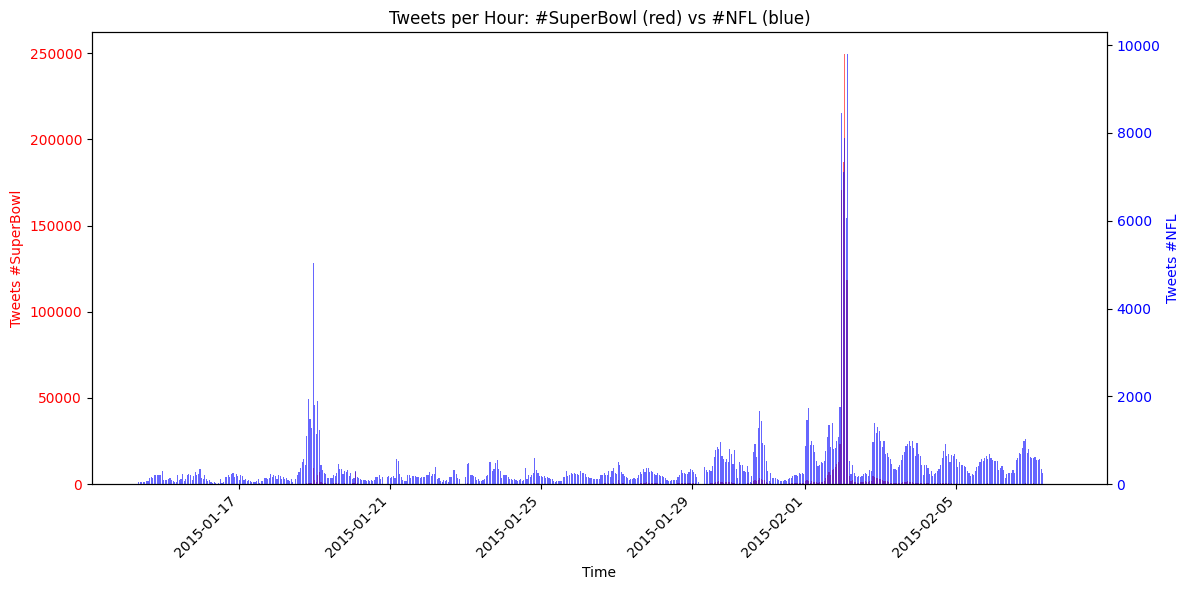

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

min_time_superbowl = datetime.fromisoformat(stats_results["superbowl"]["min_time"])
max_time_superbowl = datetime.fromisoformat(stats_results["superbowl"]["max_time"])
min_time_nfl = datetime.fromisoformat(stats_results["nfl"]["min_time"])
max_time_nfl = datetime.fromisoformat(stats_results["nfl"]["max_time"])

overall_min_time = min(min_time_superbowl, min_time_nfl)
overall_max_time = max(max_time_superbowl, max_time_nfl)

df_superbowl = compute_tweets_per_hour(superbowlLoader, overall_min_time, overall_max_time)
df_nfl = compute_tweets_per_hour(nflLoader, overall_min_time, overall_max_time)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(df_superbowl["Hour"], df_superbowl["TweetCount"], width=0.03,
        color='red', alpha=0.6, label="#SuperBowl")
ax2.bar(df_nfl["Hour"], df_nfl["TweetCount"], width=0.03,
        color='blue', alpha=0.6, label="#NFL")

ax1.set_xlabel("Time")
ax1.set_ylabel("Tweets #SuperBowl", color='red')
ax2.set_ylabel("Tweets #NFL", color='blue')
ax1.tick_params(axis='y', labelcolor='red')
ax2.tick_params(axis='y', labelcolor='blue')
plt.title("Tweets per Hour: #SuperBowl (red) vs #NFL (blue)")

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

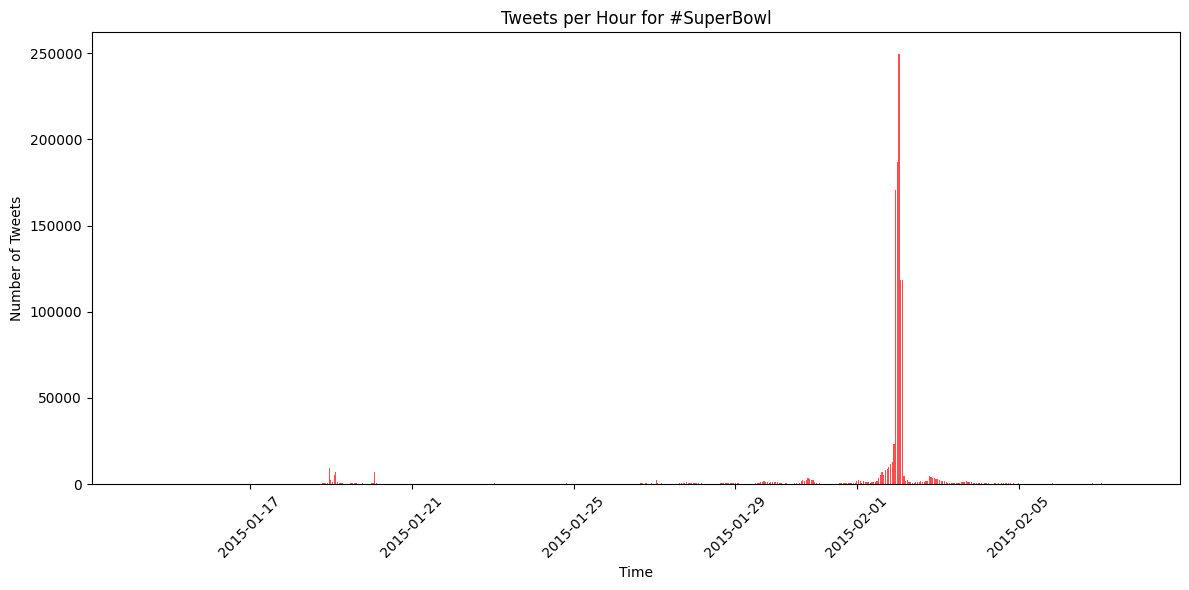

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(df_superbowl["Hour"], df_superbowl["TweetCount"], width=0.03, color='red', alpha=0.7)
plt.title("Tweets per Hour for #SuperBowl")
plt.xlabel("Time")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


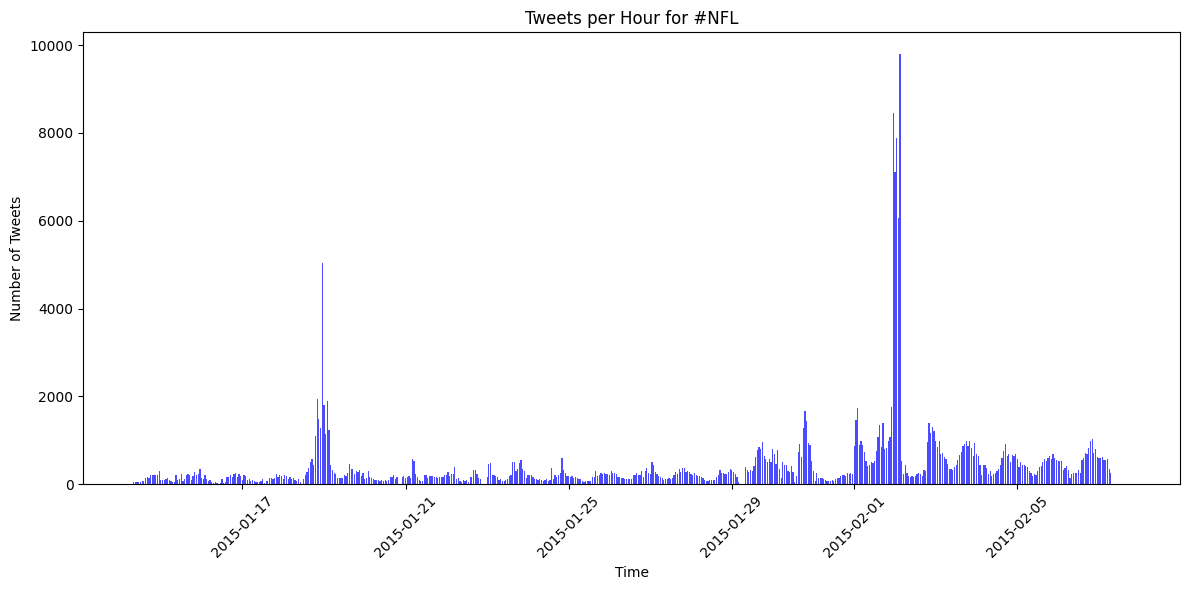

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(df_nfl["Hour"], df_nfl["TweetCount"], width=0.03, color='blue', alpha=0.7)
plt.title("Tweets per Hour for #NFL")
plt.xlabel("Time")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

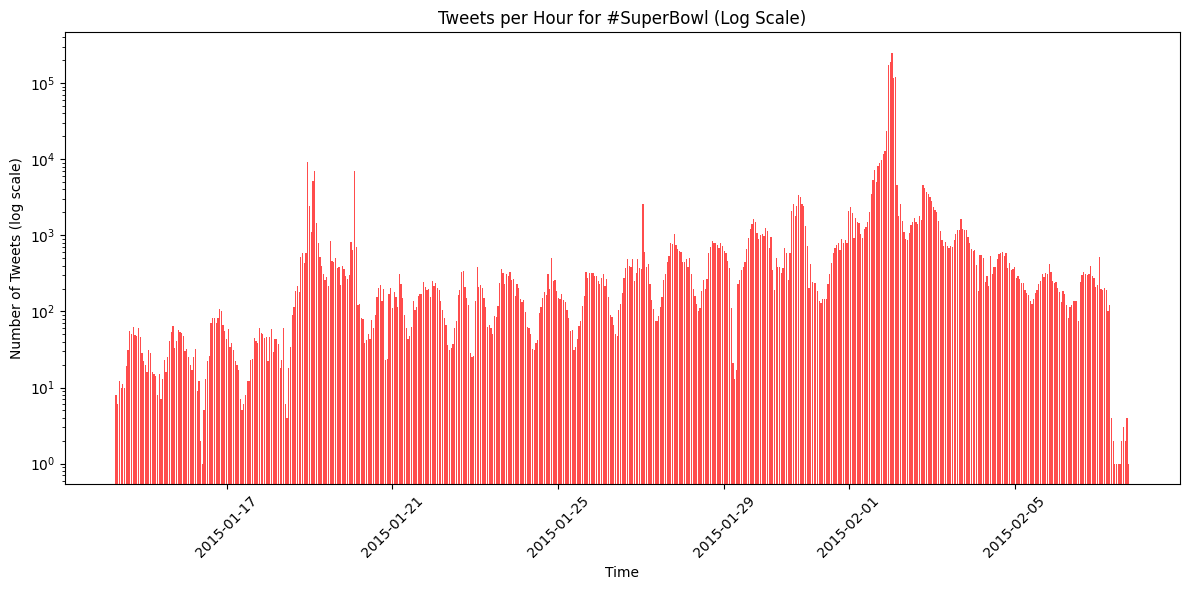

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(df_superbowl["Hour"], df_superbowl["TweetCount"], width=0.03, color='red', alpha=0.7)
plt.yscale("log")
plt.title("Tweets per Hour for #SuperBowl (Log Scale)")
plt.xlabel("Time")
plt.ylabel("Number of Tweets (log scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


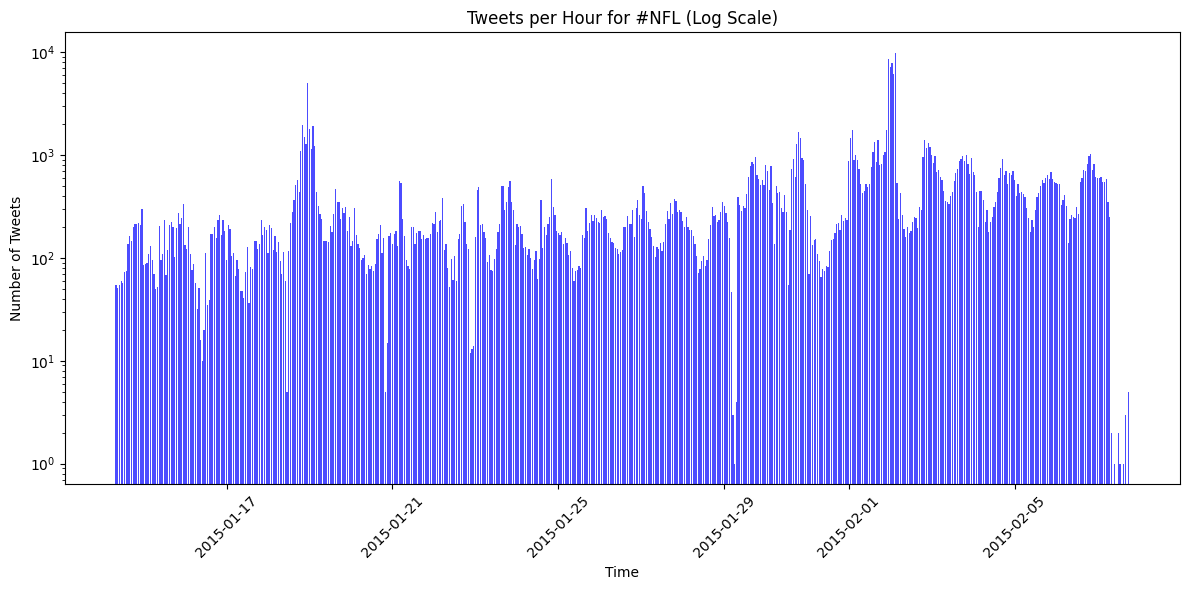

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(df_nfl["Hour"], df_nfl["TweetCount"], width=0.03, color='blue', alpha=0.7)
plt.yscale("log")
plt.title("Tweets per Hour for #NFL (Log Scale)")
plt.xlabel("Time")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

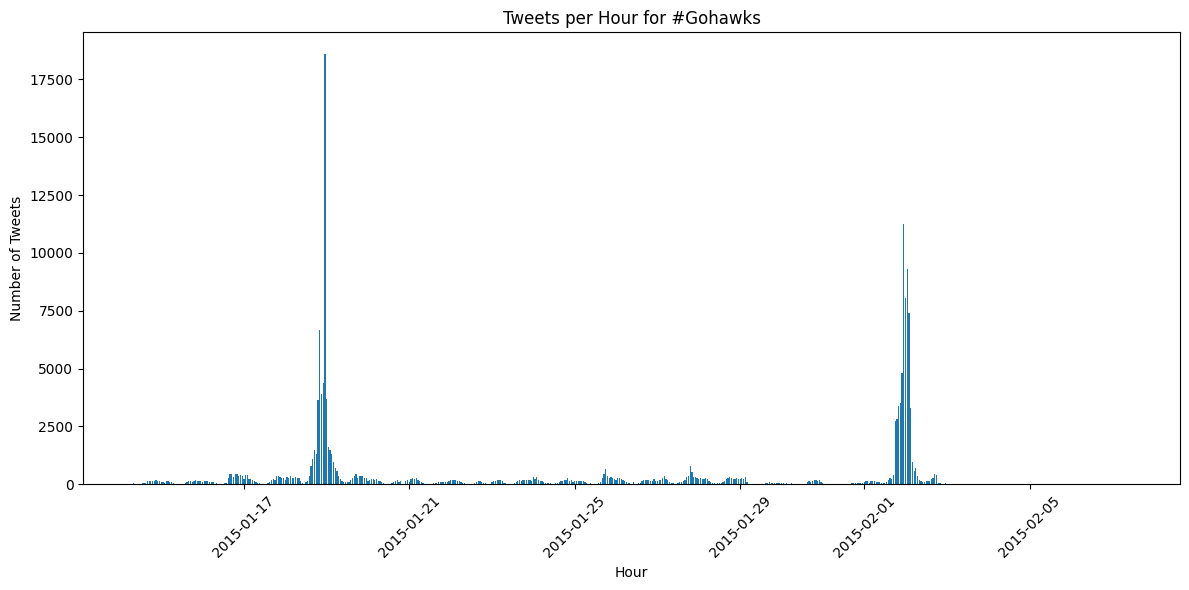

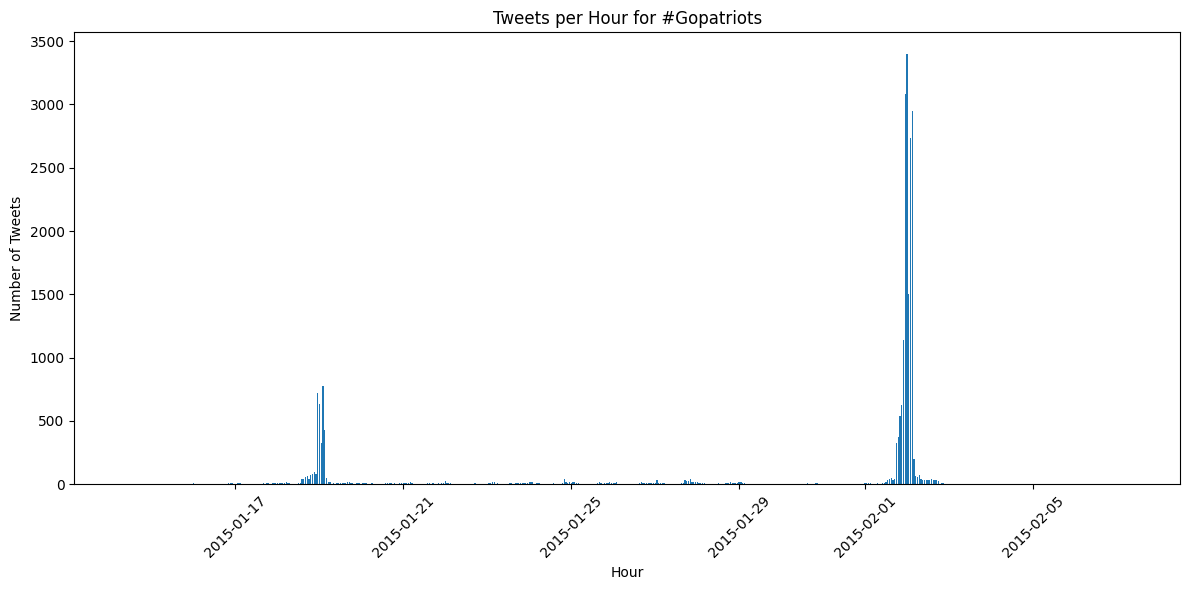

In [ ]:
for tag in ["gohawks", "gopatriots"]:
    # Get the loader and the previously computed stats.
    loader = hashtags[tag]["loader"]
    # Retrieve min_time and max_time from stats_results and convert them to datetime objects.
    min_time = datetime.fromisoformat(stats_results[tag]["min_time"])
    max_time = datetime.fromisoformat(stats_results[tag]["max_time"])

    # Compute the per-hour tweet counts using the established time window.
    df = compute_tweets_per_hour(loader, min_time, max_time)

    # Plot the bar chart.
    plt.figure(figsize=(12,6))
    plt.bar(df["Hour"], df["TweetCount"], width=0.03)  # Adjust width if needed.
    plt.title(f"Tweets per Hour for #{tag.capitalize()}")
    plt.xlabel("Hour")
    plt.ylabel("Number of Tweets")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
df

,Hour,TweetCount
0,2015-01-14 09:00:00,1
1,2015-01-14 10:00:00,1
2,2015-01-14 11:00:00,0
3,2015-01-14 12:00:00,2
4,2015-01-14 13:00:00,1
...,...,...
570,2015-02-07 03:00:00,0
571,2015-02-07 04:00:00,0
572,2015-02-07 05:00:00,0
573,2015-02-07 06:00:00,0


In [ ]:
import numpy as np

hours=5

peak=df_nfl["Hour"][np.argmax(df_nfl["TweetCount"])]
A=np.array([abs(a-peak)<=timedelta(hours=hours) for a in df_nfl["Hour"]])
print(round(np.sum(np.array(df_nfl["TweetCount"])[A])/np.sum(df_nfl["TweetCount"])*100,1),"%")

18.3 %


# Question 10

# **Predicting Tweet Impressions in a Sports Context**

## **1. Data Preprocessing and Feature Engineering**
- **Extract Relevant Tweets:**  
  - Use a dataset containing tweets related to a specific sporting event, ensuring each tweet includes metadata such as timestamp, user information, and impression count (if available).  
- **Data Cleaning:**  
  - Clean tweet texts by removing URLs, special characters, and unnecessary artifacts (e.g., emojis, HTML tags).  
- **Feature Engineering:**  
  - Extract key features such as:
    - **Tweet-based features:** Length, number of hashtags, mentions, media attachments.  
    - **User-based features:** Follower count, engagement history, verification status.  
    - **Time-based features:** Time of posting relative to game progress.  

## **2. Sentiment and Topic Analysis**
- **Sentiment Analysis:**  
  - Apply sentiment analysis (e.g., VADER or a transformer-based model) to quantify the emotional tone of each tweet.  
- **Topic Modeling:**  
  - Use LDA or BERTopic to extract themes from the tweets and determine if certain topics correlate with higher engagement.  
- **Lexical and Semantic Features:**  
  - Extract NLP-based features, including TF-IDF, word embeddings, and phrase-level insights.  

## **3. Temporal and Contextual Mapping**
- **Timestamp Normalization:**  
  - Convert timestamps to local event time, tracking how tweet timing affects impressions.  
- **Game Event Overlays:**  
  - Align tweets with in-game events (e.g., goals, touchdowns, substitutions) to explore their influence on tweet visibility.  

## **4. Model Selection and Training**
- **Data Splitting:**  
  - Split the dataset into training, validation, and test sets based on chronological order to prevent data leakage.  
- **Feature Selection and Baseline Models:**  
  - Evaluate multiple models, including linear regression, decision trees, and random forests, for baseline comparisons.  
- **Advanced Modeling:**  
  - Use deep learning models (e.g., transformers or LSTMs) to capture sequential patterns in tweet engagement.  
  - Experiment with ensemble methods for improved prediction accuracy.  

## **5. Evaluation and Interpretation**
- **Performance Metrics:**  
  - Use metrics like Mean Absolute Error (MAE) and R² to evaluate prediction accuracy.  
- **Error Analysis:**  
  - Identify underperforming cases (e.g., tweets with unexpected high or low impressions).  
- **Feature Importance Analysis:**  
  - Use SHAP values or permutation importance to interpret which features contribute most to tweet impressions.  

## **6. Application and Insights**
- **Optimization Strategies:**  
  - Recommend strategies for maximizing tweet reach based on insights from the model.  
- **Comparative Analysis:**  
  - Compare predicted impressions with actual engagement to validate the model's effectiveness in different scenarios.

In [16]:
!pip install langid

Let's get a feeling for our data.

In [6]:
import numpy as np

for i in range(15):
  print(superbowlLoader[np.random.randint(0,len(superbowlLoader))]['tweet']['text'],"\n")

-- lets go patriots #SuperBowlXLIX #SuperBowlSunday #NINERGAANG 

Missy Elliot??!!!??? That was a throw back but a good show!! #SuperBowlXLIX 

Your child wants 2b the next #SuperBowl star but u can't afford 2 send them 4 activities &amp; u live in PA,NJ,DE look: http://t.co/8Bf3MlrxBf 

Cuanta emoción ayer en #SuperBowlXLIX #NEvsSEA aqui los Highlights!! #LoveUrShirtMan #PatriotsWIN #NFLTutorialMan https://t.co/qCpN8mUgSz 

Sick of the predictions, sick of the talking...let's plsy some football!!!! #SuperBowl49 #patriots 

#throwback to michael jackson's 1993 #SuperBowl half-time show💙 http://t.co/1IE75gjjcz 

McDonalds are so full of shit. Haha. #SuperBowlXLIX 

#SuperBowl  Spin Cycle by Mixing &amp; Remixing The Hits Spin Cycle ♫ #iHeartRadio #NowPlaying http://t.co/wjIdHSEL7U http://t.co/4V4CJpv2KL 

Partidazo: NE Patriots VS Seattle Seahawks #SuperBowlXLIX #SuperBowl 

Waiting for #TheBlacklist to come on, but they keep talking about the #Superbowl. This is pretty much… http://t.c

These tweets are mainly one thing: dirty. Some consist mainly of emojis. Some are in spanish... we must filter for recognisable english containing mainly normal characters. We adapt the dataloader to filter.

In [17]:
import json
import math
import re
from datetime import datetime
import pytz
import langid

# Precompile an emoji pattern (covers common emoji ranges)
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags
                           "]+", flags=re.UNICODE)

def is_valid_tweet(tweet,p=.3):
    """
    Returns True if tweet text is recognized as English,
    is not dominated by emojis (e.g. more than p=30% of characters are emoji),
    and is not composed mainly of hashtags (e.g. more than 70% of tokens are hashtags).
    """
    # Extract text from tweet; adjust the key access if your tweet structure differs.
    text = tweet.get('tweet', {}).get('text', '')
    if not text:
        return False

    # Use langid to detect language (langid.classify is very fast)
    lang, conf = langid.classify(text)
    if lang != 'en':
        return False

    # Check the ratio of emoji characters in the text.
    total_chars = len(text)
    if total_chars > 0:
        emoji_count = len(emoji_pattern.findall(text))
        if (emoji_count / total_chars) > p:
            return False

    # Split text into tokens and check the fraction that are hashtags.
    tokens = text.split()
    if tokens:
        hashtag_count = sum(1 for token in tokens if token.startswith('#'))
        if (hashtag_count / len(tokens)) > 0.7:
            return False

    return True

import pickle

def filter(tweet, new_start_ts=None, new_end_ts=None):
  citation_date = tweet.get('citation_date')
  if new_start_ts is not None and new_end_ts is not None:
    if citation_date is None or not (new_start_ts <= citation_date <= new_end_ts):
      return False
  retweeted = tweet['tweet']['retweeted']
  if retweeted:
    return False

  return is_valid_tweet(tweet)

class FilteredDataLoader(TweetDataLoader):
    def __init__(self, hashtag, batch_size=0):
        self.hashtag = hashtag
        self.file_path = hashtags[self.hashtag]["file_path"]
        self.batch_size = batch_size

        mst_tz = pytz.timezone("MST")
        self.start_dt = datetime(2015, 2, 1, 16, 30, 0, tzinfo=mst_tz)
        self.end_dt   = datetime(2015, 2, 2, 23, 59, 59, tzinfo=mst_tz)
        self.start_ts = self.start_dt.timestamp()
        self.end_ts   = self.end_dt.timestamp()

        # Open the file and build the index.
        self.f = open(self.file_path, 'r', encoding='utf-8')
        self.offsets = []
        self._build_index()

    def _build_index(self):
        self.f.seek(0)
        pos = self.f.tell()
        line = self.f.readline()
        while line:
            try:
                tweet = json.loads(line)
            except Exception:
                pos = self.f.tell()
                line = self.f.readline()
                continue
            if filter(tweet):
                  self.offsets.append(pos)
            pos = self.f.tell()
            line = self.f.readline()

        self.filtered_count = len(self.offsets)
        if self.batch_size > 0:
            self._length = math.ceil(self.filtered_count / self.batch_size)
        else:
            self._length = self.filtered_count

    def __len__(self):
        return self._length

    def __getitem__(self, index):
        if self.batch_size == 0:
            if index < 0:
                index = self.filtered_count + index
            if index < 0 or index >= self.filtered_count:
                raise IndexError("Index out of range")
            self.f.seek(self.offsets[index])
            line = self.f.readline()
            return json.loads(line)
        else:
            if index < 0:
                index = self._length + index
            if index < 0 or index >= self._length:
                raise IndexError("Batch index out of range")
            start_index = index * self.batch_size
            end_index = min(start_index + self.batch_size, self.filtered_count)
            batch = []
            for i in range(start_index, end_index):
                self.f.seek(self.offsets[i])
                line = self.f.readline()
                batch.append(json.loads(line))
            return batch

    def cut(self, filter, silent=True):
      new_offsets = []
      for pos in self.offsets:
          self.f.seek(pos)
          line = self.f.readline()
          try:
              tweet = json.loads(line)
              if filter(tweet):
                  new_offsets.append(pos)
          except Exception:
              continue  # Skip corrupted lines
      self.offsets = new_offsets
      self.filtered_count = len(new_offsets)
      if self.batch_size > 0:
          self._length = math.ceil(len(new_offsets) / dataloader.batch_size)
      else:
          self._length = len(new_offsets)

      if not silent: print(self.hashtag+f"Loader now contains {self.filtered_count} tweets.")

      return self

    def __del__(self):
        self.f.close()

    def __getstate__(self):
        state = self.__dict__.copy()
        if 'f' in state:
            del state['f']
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        self.f = open(self.file_path, 'r', encoding='utf-8')

In [ ]:
for h in hashtags:
  print("Making cleaned Loader for #"+h)
  exec(h+"Loader = FilteredDataLoader('"+h+"')")
  exec("hashtags[h][\"loader\"] = "+h+"Loader")

Making cleaned Loader for #gohawks
Making cleaned Loader for #gopatriots
Making cleaned Loader for #nfl
Making cleaned Loader for #patriots
Making cleaned Loader for #sb49
Making cleaned Loader for #superbowl


In [10]:
for h in hashtags:
  loader=hashtags[h]["loader"]
  print(h)
  print(len(loader))
  print("")

gohawks
169122

gopatriots
23511

nfl
233022

patriots
440621

sb49
743649

superbowl
1213813



In [ ]:
for h in hashtags:
  loader = hashtags[h]["loader"]
  with open('/content/drive/MyDrive/pickles/'+h+'Loader.pkl', 'wb') as f_out:
      pickle.dump(loader, f_out)

In [18]:
for h in hashtags:
  with open('/content/drive/MyDrive/219_Final_project/pickles/'+h+'Loader.pkl', 'rb') as f_in:
      hashtags[h]['loader'] = pickle.load(f_in)
      loader=hashtags[h]['loader']
      exec(h+"Loader = loader")

In [9]:
import numpy as np
for i in range(15):
  print(superbowlLoader[np.random.randint(0,len(superbowlLoader))]['tweet']['text'],"\n")

There's one team we can all support #SuperBowl http://t.co/PahPf0Ijfb 

@Seahawks &amp; @Patriots good luck to both team in the #SuperBowl give us a good game! 

She's a lion, a dark horse. What next??? #SuperBowlXLIX #HalftimeShowKatyPerry 

How to get NFL swag — no credit card swiping required #SuperBowl 

What ever happened to a good band playing good music? #SuperBowl Halftime show. WTF was that, the opening scene to the Lion King? 

Patriots- Pass to Vareem . #SeattleSeahawks #NewEnglandPatriots #football #AmericanFootball #SuperBowl #SuperBowlXLIX #SB49 

God bless the people on the east coast..I'm happy the #SuperBowl champs are @Patriots 👍😃 So sorry the celebration is postponed by ⛄️😒 

Magical Interception but Sherman tho!  #patriots #SB49 #SuperBowlXLIX #RichardSherman #Seahawks #funny https://t.co/OTVgn56YGZ 

Yay @katyperry is on! Now it's time to watch the #SuperBowl #Halftime #SuperBowlXLIX 

#SuperBowl #seahawks in trouble. Defence too banged up 

Which one is your favor

In [19]:
for k in superbowlLoader[0]:
    print(type(superbowlLoader[0][k])==dict)

False
False
False
True
True
True
False
True
False
False
False


In [26]:
tweet = superbowlLoader[0]

print(tweet['tweet']['text'],
      tweet['firstpost_date'],
      tweet['tweet']['user']['verified'],
      tweet['author']['name'],
      tweet['metrics']['impressions'])

At http://t.co/Vd0RWOeAed -- #Seahawks #12thMAN #12 #SeahawkNation #SuperBowlBound #Superbowl #Repeat #GoHawks ... http://t.co/XSEFUKqEhN 1419883838 False Becca Delgado 5


In [27]:
import pandas as pd
import pickle
from tqdm import tqdm
import csv

# Path to your pickles
pickle_dir = "/content/drive/MyDrive/219_Final_project/pickles/"
pickle_files = [
    "superbowlLoader.pkl",
    "sb49Loader.pkl",
    "patriotsLoader.pkl",
    "nflLoader.pkl",
    "gopatriotsLoader.pkl",
    "gohawksLoader.pkl"
]

# Flatten function (as before)
def flatten_json(tweet):
    return {
        'text': tweet['tweet']['text'],
        'time': tweet['firstpost_date'],
        'verified': tweet['tweet']['user']['verified'],
        'author': tweet['author']['name'],
        'impressions': tweet['metrics']['impressions']
    }

# Output CSV file
output_csv_path = "/content/drive/MyDrive/219_Final_project/all_tweets_flat.csv"

# Initialize CSV file with header
with open(output_csv_path, mode='w', newline='', encoding='utf-8') as f_out:
    writer = csv.DictWriter(f_out, fieldnames=['text', 'time', 'verified', 'author', 'impressions'])
    writer.writeheader()


In [30]:
# Now process each pickle and append tweets to the CSV
for file_name in pickle_files:
    print(f"Processing {file_name} ...")
    with open(pickle_dir + file_name, 'rb') as f_in:
        tweet_loader = pickle.load(f_in)

    # Write in chunks to avoid memory overload
    with open(output_csv_path, mode='a', newline='', encoding='utf-8') as f_out:
        writer = csv.DictWriter(f_out, fieldnames=['text', 'time', 'verified', 'author', 'impressions'])
        for tweet in tqdm(tweet_loader):
            flat_tweet = flatten_json(tweet)
            writer.writerow(flat_tweet)


Processing superbowlLoader.pkl ...


  1%|          | 9326/918021 [00:00<01:20, 11251.71it/s]


KeyboardInterrupt: 

In [31]:
for i in range(1000):
    try: superbowlLoader[i]['firstpost_date']
    except: print(i)

# Feature engineering

In [1]:
# Import everything
import torchvision
!pip install ethnicolr
import ethnicolr
import torchvision

import os
import re
import json
import math
import random
import pickle
import numpy as np
import pandas as pd
from datetime import datetime
import pytz

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [32]:
def clean_text(text):
    """
    Clean tweet text by removing URLs, HTML tags, non-ASCII characters,
    and extra whitespace.
    """
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove non-ASCII characters (this may remove emojis)
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text



For demographic information from the name we will use a pretrained model, namely the one developed [here](https://aclanthology.org/W18-1114.pdf):

Predicting Twitter User Demographics from Names Alone
Zach Wood-Doughty, Nicholas Andrews, Rebecca Marvin, Mark Dredze
Center for Language and Speech Processing
Johns Hopkins University, Baltimore, MD 21218

In [3]:
from transformers import pipeline

model_name = "padmajabfrl/Gender-Classification"
classifier = pipeline("text-classification", model=model_name, trust_remote_code=True)
print(classifier("Hello world!"))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/360 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


[{'label': 'Female', 'score': 0.9857402443885803}]


In [4]:
import pandas as pd
import numpy as np
import ethnicolr as ec
from transformers import pipeline


# Initialize the gender classifier pipeline.
gender_classifier = pipeline(
    "text-classification",
    model="padmajabfrl/Gender-Classification",
    tokenizer="padmajabfrl/Gender-Classification"
)

def splitname(s: str) -> tuple[str, str]:
    """
    Splits name into first and last.
    """
    s = s.strip()
    idx = s.rfind(' ')
    if idx == -1:
        return ("", s)  # No spaces found
    return (s[:idx], s[idx+1:])

def get_race_prediction(full_name: str) -> str:
    """
    Predicts race from a full name using ethnicolr's Florida model.
    Returns the predicted race as a string.
    """
    df_temp = pd.DataFrame({"name": [full_name]})
    df_temp[['fname', 'lname']] = df_temp['name'].apply(lambda x: pd.Series(splitname(x)))
    df_temp = ec.pred_fl_reg_name(df_temp,"fname","lname")
    # Ethnicolr's function typically adds a 'race' column with the prediction.
    return df_temp.loc[0, "race"]

def get_gender_prediction(full_name: str) -> str:
    """
    Predicts gender from a full name using the padmajabfrl/Gender-Classification model.
    Returns the predicted gender (e.g., 'male' or 'female') as a string.
    """
    result = gender_classifier(full_name)
    return result[0]['label'].lower()

# Define fixed dense vectors for each predicted race.
race_to_vector = {
    "white": np.eye(1,5,0).squeeze(),
    "black": np.eye(1,5,1).squeeze(),
    "asian": np.eye(1,5,2).squeeze(),
    "hispanic": np.eye(1,5,3).squeeze(),
    "other": np.eye(1,5,4).squeeze()}

# Define fixed dense vectors for each predicted gender.
gender_to_vector = {
    "male": np.array([1]),
    "female": np.array([-1]),
    "unknown": np.array([0])
}

def get_demographic_embedding(full_name: str) -> np.ndarray:
    """
    Given a full name, uses ethnicolr to predict race and a pretrained gender classifier to predict gender.
    Then, maps the race and gender predictions to fixed dense vectors and concatenates them into a single vector.

    Returns:
        A numpy array representing the combined demographic embedding.
    """
    race = get_race_prediction(full_name)
    gender = get_gender_prediction(full_name)

    # Map predictions to dense vectors. Use "other" and "unknown" as defaults.
    race_vec = race_to_vector.get(race.lower(), race_to_vector["other"])
    gender_vec = gender_to_vector.get(gender.lower(), gender_to_vector["unknown"])

    # Concatenate the race vector and the gender vector.
    combined_embedding = np.concatenate([race_vec, gender_vec])
    return combined_embedding

# Example usage:
if __name__ == "__main__":
    sample_name = "Kim JongUn"
    demo_embedding = get_demographic_embedding(sample_name)
    print("Combined Demographic Embedding for", sample_name)
    print("Shape:", demo_embedding.shape)
    print("Embedding vector:", demo_embedding)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Device set to use cuda:0


Combined Demographic Embedding for Kim JongUn
Shape: (6,)
Embedding vector: [0. 0. 1. 0. 0. 1.]


In [5]:
# Load a pretrained SentenceTransformer for tweet text representation.
from sentence_transformers import SentenceTransformer
tweet_text_model = SentenceTransformer('all-MiniLM-L6-v2')

def get_tweet_text_embedding(text: str) -> np.ndarray:
    """
    Returns a dense vector representation of the input tweet text using a pretrained model.
    """
    cleaned = clean_text(text)
    return tweet_text_model.encode(cleaned)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
def get_time_representation(timestamp: float) -> np.ndarray:
    """
    Given a UNIX timestamp, returns a 4-dimensional cyclical time representation:
      [sin(2π*hour/24), cos(2π*hour/24), sin(2π*day/7), cos(2π*day/7)]
    """
    dt = datetime.fromtimestamp(timestamp)
    minute=dt.minute
    hour = dt.hour
    day = dt.weekday()  # Monday = 0, Sunday = 6
    sin_minute = np.sin(2 * np.pi * minute / 60)
    cos_minute = np.cos(2 * np.pi * minute / 60)
    sin_hour = np.sin(2 * np.pi * hour / 24)
    cos_hour = np.cos(2 * np.pi * hour / 24)
    sin_day = np.sin(2 * np.pi * day / 7)
    cos_day = np.cos(2 * np.pi * day / 7)
    return np.array([sin_minute,cos_minute,sin_hour, cos_hour, sin_day, cos_day])

def get_date_representation(timestamp: float) -> np.ndarray:
    """
    Given a UNIX timestamp, returns a 1-dimensional vector representing the absolute date.
    Here we convert the date to an ordinal (number of days since (2015, 2, 1)).
    """
    dt = datetime.fromtimestamp(timestamp)
    ref_date = datetime(2015, 2, 1)
    ordinal = dt.toordinal() - ref_date.toordinal()
    return np.array([ordinal])


In [7]:
import numpy as np
from datetime import datetime
from sentence_transformers import SentenceTransformer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer.
sentiment_analyzer = SentimentIntensityAnalyzer()

def get_combined_representation(tweet: dict) -> np.ndarray:
    """
    Given a tweet dictionary with keys:
      - 'tweet_text': raw tweet text.
      - 'timestamp': tweet timestamp (in seconds).
      - 'user_name': user's full name.
      - 'verified': boolean indicating if user is verified.

    Returns a vector by concatenating:
      1. Tweet text embedding.
      2. Cyclical time representation (4 dims).
      3. Absolute date representation (1 dim).
      4. Demographic embedding from the user's name.
      5. Sentiment representation (1 dim).
      6. Verified status (1 dim, as float 1.0 or 0.0).
    """
    # Tweet text embedding.
    text = tweet.get('tweet_text', '')
    text_emb = get_tweet_text_embedding(text)

    # Time and date representations.
    ts = tweet.get('timestamp', None)
    if ts is None:
        time_emb = np.zeros(4)
        date_emb = np.zeros(1)
    else:
        ts = float(ts)
        time_emb = get_time_representation(ts)
        date_emb = get_date_representation(ts)

    # Demographic embedding.
    name = tweet.get('user_name', '')
    demo_emb = get_demographic_embedding(name)

    # Sentiment representation.
    cleaned = clean_text(text)
    sentiment = sentiment_analyzer.polarity_scores(cleaned)['compound']
    sentiment_emb = np.array([sentiment])

    # Verified status as float.
    verified_flag = 1.0 if tweet.get('verified', False) else -1.0
    verified_emb = np.array([verified_flag])

    # Concatenate all features into one vector.
    combined_vector = np.concatenate([text_emb, time_emb, date_emb, demo_emb, sentiment_emb, verified_emb])
    return combined_vector

In [8]:
tweet={"tweet_text" : "I absolutely hate this game and especially that dickhead tom brady!",
      'timestamp': 1419883838,
      'user_name': "yuanyi yang",
      'verified': True
}

In [9]:
get_combined_representation(tweet).shape

(399,)

In [10]:
print(get_combined_representation(tweet))

[-3.83004472e-02  7.31776655e-02  1.82008091e-02 -1.87365100e-01
  6.81769103e-02 -1.86250266e-02 -3.20706740e-02  3.74338254e-02
  8.39423165e-02  5.10790236e-02 -8.38662758e-02 -1.26404418e-02
  8.54208767e-02 -1.52010368e-02 -1.02417305e-01 -9.93942004e-03
 -4.36289832e-02  1.68777164e-02  7.42347986e-02  8.91406741e-03
 -6.49267584e-02  1.03673622e-01 -8.18080083e-02 -9.44703165e-03
 -5.02187312e-02 -1.11356908e-02  5.16900010e-02  2.24986561e-02
 -1.00287519e-01 -8.36424008e-02  8.96348432e-02 -3.10084373e-02
 -1.26406401e-02 -2.88689267e-02 -9.17212293e-02  4.66750516e-03
  1.46747855e-02 -1.92168187e-02  5.29285260e-02  5.29416725e-02
 -3.50605473e-02 -2.28044167e-02  5.93337417e-02  3.62425782e-02
 -2.79110856e-03  3.49369453e-04 -5.75162843e-03 -7.01493621e-02
  1.23996146e-01 -2.56053768e-02  5.87602258e-02  4.33790758e-02
  8.24870914e-03 -1.56401545e-02  3.57825719e-02  3.56494039e-02
  5.16157597e-02  5.48866689e-02 -5.93955331e-02  1.99110787e-02
 -4.83915918e-02 -3.59567

In [33]:
df = pd.read_csv(output_csv_path)
print(df.head())


                                                text        time  verified  \
0  At http://t.co/Vd0RWOeAed -- #Seahawks #12thMA...  1419883838     False   
1  You been 12ed pass it on #SeahawkNation #LOB #...  1420343180     False   
2  27 days to the SuperBowl 🏈🏈\n#Katyperry #KatyC...  1420354386     False   
3  Check out the cool event that  #budlight has p...  1420662396     False   
4  Our @ButchStearns talked #Patriots w/3X #Super...  1421030046      True   

                author  impressions  
0        Becca Delgado            5  
1        Becca Delgado            4  
2        Walterlinesjr          833  
3        EventMarketer        13943  
4  Coach Chrissy Carew         5580  


In [34]:
# Check for GPU (T4)
import torch
print(torch.cuda.get_device_name(0))

# Install dependencies
!pip install sentence-transformers ethnicolr transformers nltk

import nltk
nltk.download('vader_lexicon')


Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [35]:
# Clean tweet text
def clean_text(text):
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    return re.sub(r'\s+', ' ', text).strip()

# Time & date features
def get_time_representation(timestamp):
    dt = datetime.fromtimestamp(timestamp)
    return np.array([
        np.sin(2 * np.pi * dt.minute / 60),
        np.cos(2 * np.pi * dt.minute / 60),
        np.sin(2 * np.pi * dt.hour / 24),
        np.cos(2 * np.pi * dt.hour / 24),
        np.sin(2 * np.pi * dt.weekday() / 7),
        np.cos(2 * np.pi * dt.weekday() / 7)
    ])

def get_date_representation(timestamp):
    ref_date = datetime(2015, 2, 1)
    dt = datetime.fromtimestamp(timestamp)
    return np.array([dt.toordinal() - ref_date.toordinal()])


In [36]:
# Device selection
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# SentenceTransformer on GPU
tweet_text_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# VADER sentiment analyzer
sentiment_analyzer = SentimentIntensityAnalyzer()

# Gender classifier on GPU
gender_classifier = pipeline(
    "text-classification",
    model="padmajabfrl/Gender-Classification",
    tokenizer="padmajabfrl/Gender-Classification",
    device=0 if torch.cuda.is_available() else -1
)


Device set to use cuda:0


In [37]:
# Demographic vector mapping
race_to_vector = {
    "white": np.eye(1,5,0).squeeze(),
    "black": np.eye(1,5,1).squeeze(),
    "asian": np.eye(1,5,2).squeeze(),
    "hispanic": np.eye(1,5,3).squeeze(),
    "other": np.eye(1,5,4).squeeze()
}
gender_to_vector = {
    "male": np.array([1]),
    "female": np.array([-1]),
    "unknown": np.array([0])
}

def splitname(s):
    idx = s.strip().rfind(' ')
    return ("", s) if idx == -1 else (s[:idx], s[idx+1:])

def get_race_prediction(full_name):
    df_temp = pd.DataFrame({"name": [full_name]})
    df_temp[['fname', 'lname']] = df_temp['name'].apply(lambda x: pd.Series(splitname(x)))
    df_temp = ec.pred_fl_reg_name(df_temp, "fname", "lname")
    return df_temp.loc[0, "race"]

def get_gender_prediction(full_name):
    result = gender_classifier(full_name)
    return result[0]['label'].lower()

def get_demographic_embedding(full_name):
    race = get_race_prediction(full_name)
    gender = get_gender_prediction(full_name)
    race_vec = race_to_vector.get(race.lower(), race_to_vector["other"])
    gender_vec = gender_to_vector.get(gender.lower(), gender_to_vector["unknown"])
    return np.concatenate([race_vec, gender_vec])

# Full feature vector creation
def get_combined_representation(tweet):
    text = tweet.get('tweet_text', '')
    text_emb = tweet_text_model.encode(clean_text(text), device=device)

    ts = float(tweet.get('timestamp', 0))
    time_emb = get_time_representation(ts)
    date_emb = get_date_representation(ts)

    name = tweet.get('user_name', '')
    demo_emb = get_demographic_embedding(name)

    sentiment = sentiment_analyzer.polarity_scores(clean_text(text))['compound']
    sentiment_emb = np.array([sentiment])

    verified_emb = np.array([1.0 if tweet.get('verified', False) else -1.0])

    return np.concatenate([text_emb, time_emb, date_emb, demo_emb, sentiment_emb, verified_emb])


In [38]:
# # Load CSV with real impressions
# csv_path = "/content/drive/MyDrive/219_Final_project/all_tweets_flat.csv"
# df = pd.read_csv(csv_path)

# # Process rows into features + targets
# features = []
# targets = []

# for _, row in tqdm(df.iterrows(), total=len(df)):
#     tweet_dict = {
#         "tweet_text": row['text'],
#         "timestamp": row['time'],
#         "user_name": row['author'],
#         "verified": bool(row['verified'])
#     }
#     try:
#         vec = get_combined_representation(tweet_dict)
#         features.append(vec)
#         targets.append(row['impressions'])
#     except Exception as e:
#         print(f"Skipping tweet due to error: {e}")
#         continue

# X = np.vstack(features)
# y = np.array(targets)


  0%|          | 214/2337437 [00:38<98:58:33,  6.56it/s]ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend.py", line 5158, in <genexpr>
    output_ta_t = tuple(  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/util/tf_should_use.py", line 288, in wrapped
    return _add_should_use_warning(fn(*args, **kwargs),
  0%|          | 1041/2337437 [03:06<116:06:11,  5.59it/s]


KeyboardInterrupt: 

Dataset is far too large (2 million tweets). I cannot process this. We will randomly sample 10k tweets for a smlaller dataset to train and test on.

In [39]:
# Sample 10,000 tweets
df_sampled = df.sample(n=10000, random_state=42).reset_index(drop=True)

features = []
targets = []

for _, row in tqdm(df_sampled.iterrows(), total=len(df_sampled)):
    tweet_dict = {
        "tweet_text": row['text'],
        "timestamp": row['time'],
        "user_name": row['author'],
        "verified": bool(row['verified'])
    }
    try:
        vec = get_combined_representation(tweet_dict)
        features.append(vec)
        targets.append(row['impressions'])
    except Exception as e:
        print(f"Skipped tweet due to error: {e}")
        continue

# Convert to arrays
X = np.vstack(features)
y = np.array(targets)


100%|██████████| 10000/10000 [29:54<00:00,  5.57it/s]


In [40]:
# Save feature vectors (X) and targets (y)
np.savez('/content/drive/MyDrive/219_Final_project/features_targets_10k.npz', X=X, y=y)
print("Saved features and targets!")


Saved features and targets!


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 18498.841464795514
R² Score: 0.058714987097721605


In [55]:
print(f"Mean Error: {np.mean(errors):,.0f}")
print(f"Median Error: {np.median(errors):,.0f}")
print(f"Max Error: {np.max(errors):,.0f}")
print(f"Min Error: {np.min(errors):,.0f}")


Mean Error: -4,629
Median Error: -512
Max Error: 8,240,246
Min Error: -1,705,739


In [67]:
# Compute absolute percentage error
percentage_error = np.abs((y_test - y_pred) / (y_test + 0.00000000001))

# Define correctness threshold (10% error)
threshold = 0.10  # 10%
correct_mask = percentage_error <= threshold

# Count correct predictions
num_correct = np.sum(correct_mask)
total = len(y_test)
accuracy = num_correct / total * 100

print(f"Correct Predictions (±10%): {num_correct} / {total} ({accuracy:.2f}%)")


Correct Predictions (±10%): 88 / 2000 (4.40%)


In [42]:
import joblib
joblib.dump(rf, '/content/drive/MyDrive/219_Final_project/rf_model_10k.joblib')


['/content/drive/MyDrive/219_Final_project/rf_model_10k.joblib']

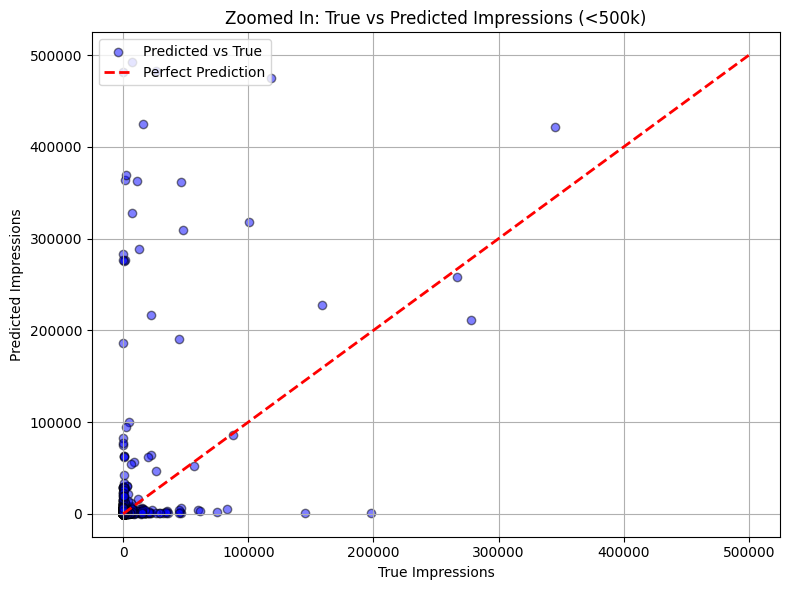

In [47]:
# Filter to low-range impressions
mask = (y_test < 500000) & (y_pred < 500000)

plt.figure(figsize=(8,6))
plt.scatter(y_test[mask], y_pred[mask], alpha=0.5, color='blue', edgecolor='k', label='Predicted vs True')
plt.plot([0, 500000], [0, 500000], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('True Impressions')
plt.ylabel('Predicted Impressions')
plt.title('Zoomed In: True vs Predicted Impressions (<500k)')
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


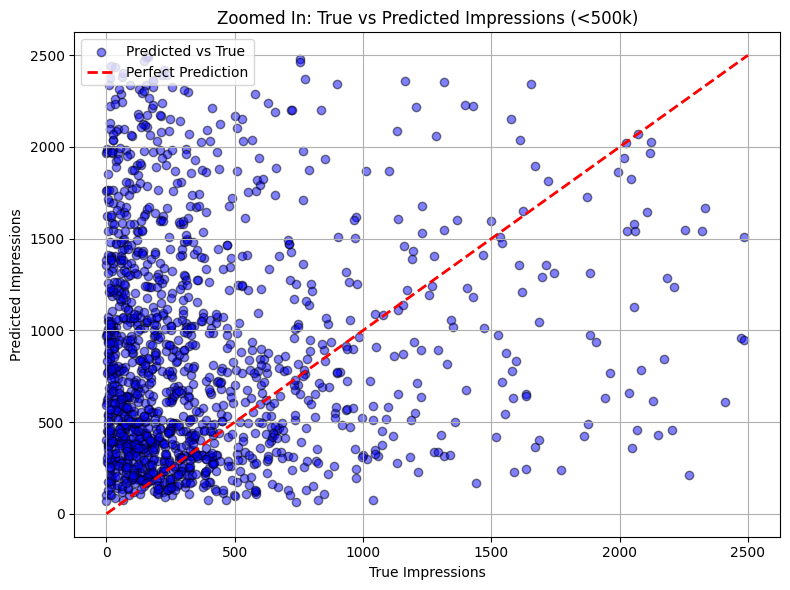

In [54]:
# Filter to low-range impressions
mask = (y_test < 2500) & (y_pred < 2500)

plt.figure(figsize=(8,6))
plt.scatter(y_test[mask], y_pred[mask], alpha=0.5, color='blue', edgecolor='k', label='Predicted vs True')
plt.plot([0, 2500], [0, 2500], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('True Impressions')
plt.ylabel('Predicted Impressions')
plt.title('Zoomed In: True vs Predicted Impressions (<500k)')
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


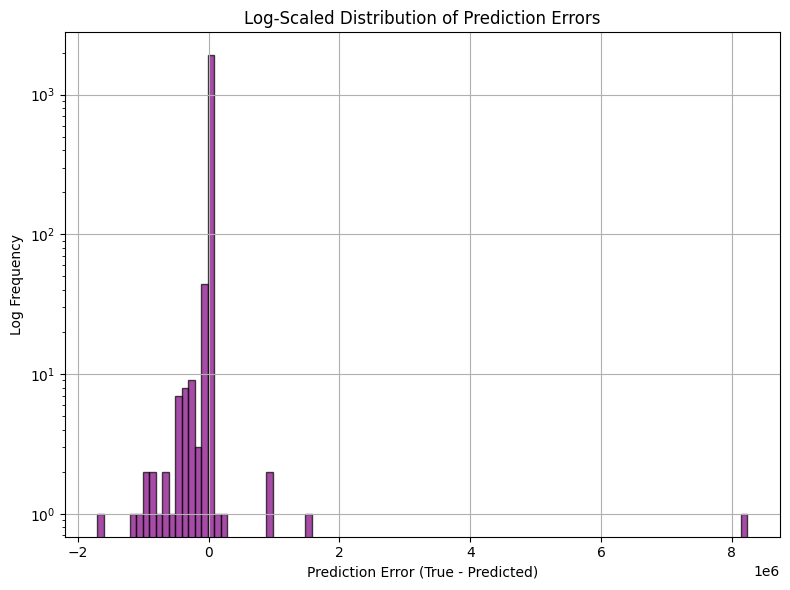

In [66]:
plt.figure(figsize=(8,6))
plt.hist(errors, bins=100, color='purple', edgecolor='black', alpha=0.7, log=True)
plt.xlabel('Prediction Error (True - Predicted)')
plt.ylabel('Log Frequency')
plt.title('Log-Scaled Distribution of Prediction Errors')
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
# Absolute error for each prediction
abs_errors = np.abs(errors)

# Indices of top 5 largest errors
top_indices = np.argsort(abs_errors)[-5:]

# Show True vs Predicted for worst 5
for idx in top_indices[::-1]:
    print(f"True: {y_test[idx]:,.0f}, Predicted: {y_pred[idx]:,.0f}, Error: {errors[idx]:,.0f}")


True: 9,181,770, Predicted: 941,524, Error: 8,240,246
True: 1,562, Predicted: 1,707,301, Error: -1,705,739
True: 1,693,181, Predicted: 122,347, Error: 1,570,834
True: 1,405, Predicted: 1,196,286, Error: -1,194,881
True: 1,522, Predicted: 1,012,007, Error: -1,010,485


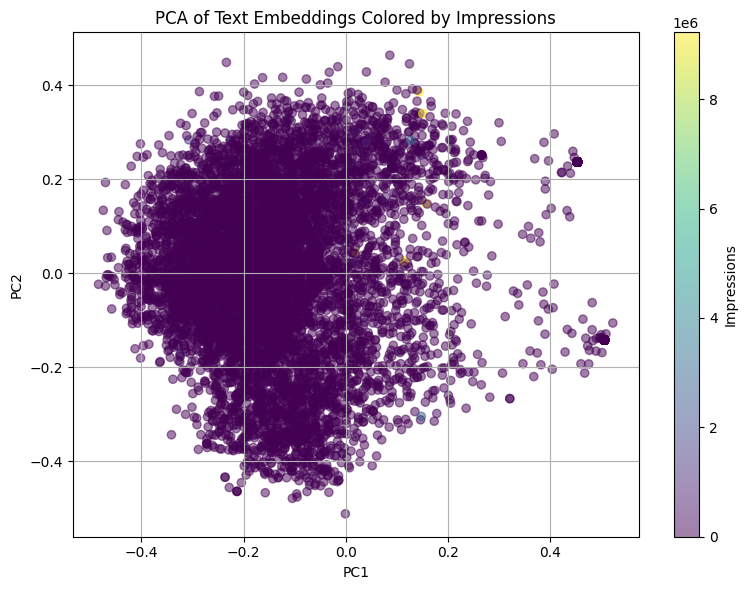

In [74]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA on text embeddings
pca = PCA(n_components=2)
X_text_only = df_features[[col for col in df_features.columns if 'text_emb' in col]].values
X_pca = pca.fit_transform(X_text_only)

# Plot PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_features['impressions'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Impressions')
plt.title('PCA of Text Embeddings Colored by Impressions')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()


In [75]:
 # Top 10 most important text embedding dimensions
for i in indices:
    if 'text_emb' in columns[i]:
        print(f"{columns[i]}: {importances[i]:.4f}")


text_emb_348: 0.0556
text_emb_195: 0.0540
text_emb_2: 0.0462
text_emb_24: 0.0414
text_emb_25: 0.0376
text_emb_68: 0.0332
text_emb_292: 0.0276
text_emb_154: 0.0262
text_emb_352: 0.0252
text_emb_286: 0.0218
text_emb_33: 0.0185
text_emb_79: 0.0175
text_emb_34: 0.0164
text_emb_339: 0.0152
text_emb_210: 0.0140
text_emb_285: 0.0134
text_emb_365: 0.0121
text_emb_117: 0.0093
text_emb_368: 0.0087
text_emb_376: 0.0083
text_emb_105: 0.0080
text_emb_282: 0.0078
text_emb_218: 0.0072
text_emb_139: 0.0070
text_emb_364: 0.0065
text_emb_246: 0.0061
text_emb_127: 0.0059
text_emb_312: 0.0057
text_emb_347: 0.0056
text_emb_369: 0.0056
text_emb_13: 0.0055
text_emb_54: 0.0054
text_emb_100: 0.0052
text_emb_326: 0.0051
text_emb_349: 0.0049
text_emb_60: 0.0048
text_emb_199: 0.0046
text_emb_130: 0.0046
text_emb_356: 0.0045
text_emb_329: 0.0045
text_emb_362: 0.0044
text_emb_51: 0.0044
text_emb_18: 0.0043
text_emb_371: 0.0042
text_emb_99: 0.0041
text_emb_138: 0.0041
text_emb_300: 0.0041
text_emb_129: 0.0041
text_e

Goal: Understand Feature Impact Using SHAP

100%|===================| 1997/2000 [05:37<00:00]       

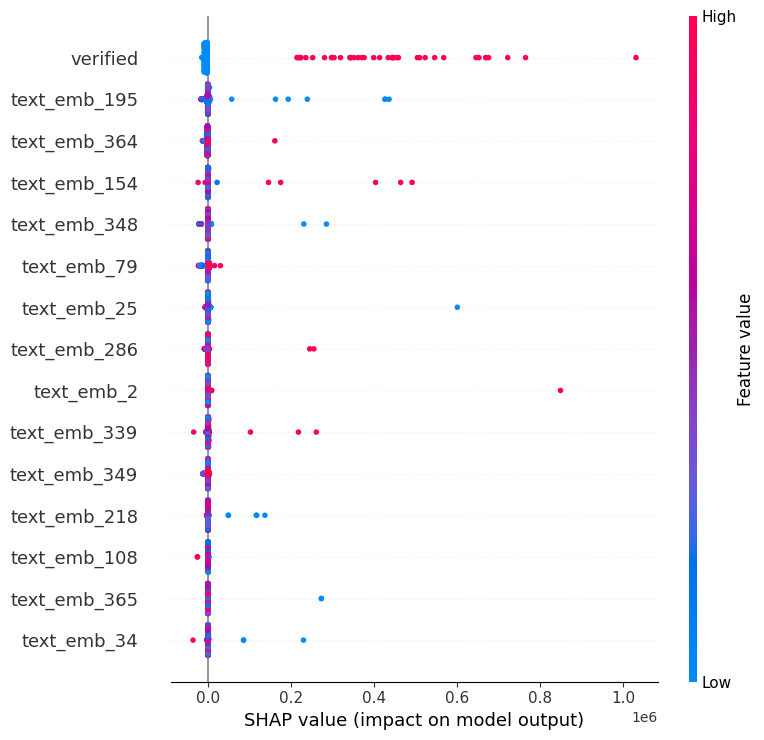

ValueError: visualize() can only display Explanation objects (or arrays of them)!

In [77]:
!pip install shap

import shap
import matplotlib.pyplot as plt

import shap

# Create SHAP explainer for Random Forest
explainer = shap.Explainer(rf, X_train)  # Use your trained rf model

# Compute SHAP values
shap_values = explainer(X_test)

# Plot summary of feature impact
shap.summary_plot(shap_values, X_test, feature_names=columns, max_display=15)

# Choose one tweet sample
idx = 0
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[idx], X_test[idx], feature_names=columns)

shap.plots.bar(shap_values, max_display=15)


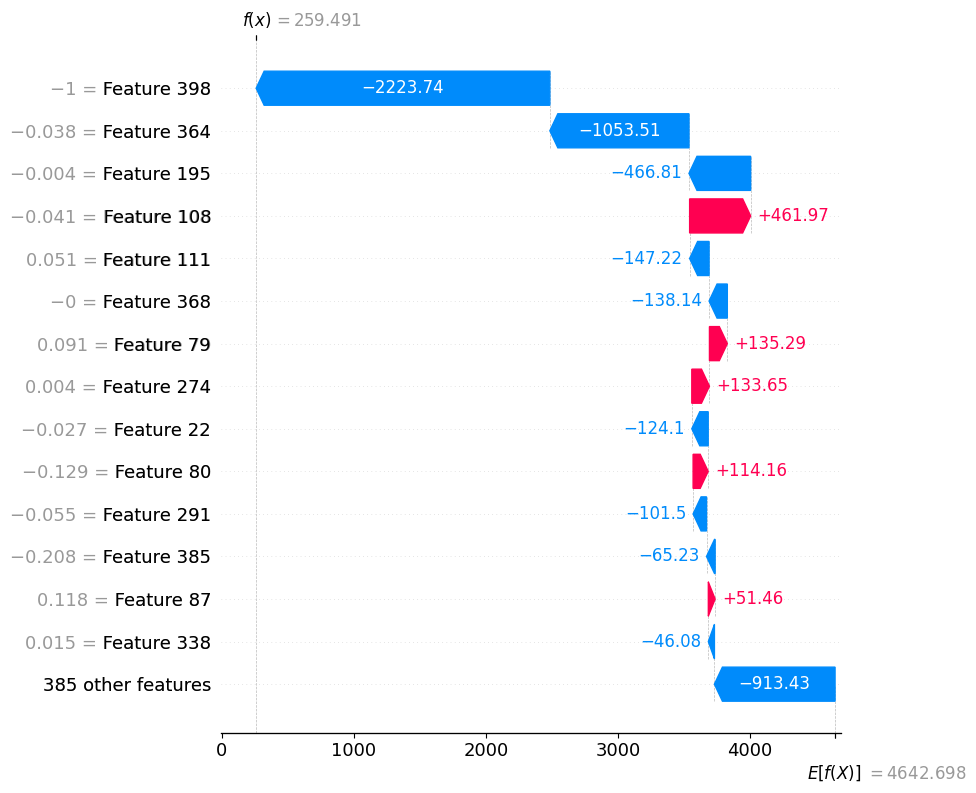

In [78]:
shap.plots.waterfall(shap_values[idx], max_display=15)


- E[f(X)] = 4642.698: The average model prediction (baseline, across all data).
- f(x) = 259.491: The prediction for this specific tweet.
- The model reduced the prediction from ~4643 to ~259 due to negative feature impacts.

##What we have completed:
- Loaded tweet data → extracted text, time, verified status, author, impressions.
- Created feature vectors:

    - Text embeddings (384-dim)
    - Time/date, demographics, sentiment, verified (15-dim)
- Trained Random Forest → predicted impressions
→ Evaluated with MAE, R², error plots.
- Explained model with SHAP: identified which features/text patterns drove predictions.
- Visualized insights